In [205]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import os

from torch.utils.benchmark.examples.spectral_ops_fuzz_test import BENCHMARK_MAP

In [206]:
BENCHMARK_RESULTS_DIR = "."
Q_FLAIR_RESULTS_DIR = "." #"../Results/Data_QNN"

# Load accuracy results

In [207]:
def line_to_dict(line: str):
    line = line.strip().split()
    return dict(zip(line[::2], line[1::2]))

def load(bench_folder, max_n_gate, acc_format_filename="ACC_classical_surrogate_{}.txt"):
    model_infos = []
    accuracy_dfs = []
    for n_gate in range(1, max_n_gate + 1):
        acc_filename = os.path.join(BENCHMARK_RESULTS_DIR, bench_folder, acc_format_filename.format(n_gate))
        # print first line:
        with open(acc_filename, 'r') as f:
            first_line = f.readline()
            model_infos.append(line_to_dict(first_line))
            accuracy_dicts = []
            for line in f:
                if line.strip() == "":
                    continue
                accuracy_dicts.append(line_to_dict(line))
            if len(accuracy_dicts) > 0:
                acc_df = pd.DataFrame(accuracy_dicts).apply(pd.to_numeric, errors='ignore')
                accuracy_dfs.append(acc_df)
    return model_infos, accuracy_dfs

def combine_accuracies(accuracy_dfs, max_col_name):
    results = []
    for n_gate, df in enumerate(accuracy_dfs):
        if df is None:
            continue
        max_row = df.loc[df[max_col_name].idxmax()]
        results.append({'n_gate': n_gate + 1, **max_row.to_dict()})
    aggregated_results = pd.DataFrame(results)
    return aggregated_results

# Visualize

In [208]:
def plot_classical_surrogate_acc(bench_folder, max_n_gate, max_col_name, ax=None, add_best_line=False, include_train_acc=False, data_set_color='blue'):
    model_infos, acc_dfs = load(bench_folder, max_n_gate=max_n_gate)
    comb_df = combine_accuracies(acc_dfs, max_col_name=max_col_name)
    if ax is None:
        ax = plt.gca()
    if include_train_acc:
        ax.plot(comb_df['n_gate'], 100 * comb_df['train_acc'], label='Classical\nSurrogate (Train)', color='grey', linestyle='--')
    ax.plot(comb_df['n_gate'], 100 * comb_df['val_acc'], label='Classical\nSurrogate', linestyle='--', color=data_set_color)
    if add_best_line:
        best_acc = comb_df['val_acc'].max()
        ax.axhline(100 * best_acc, linestyle=':', label='Best Accuracy', color='black')
    return model_infos, comb_df

([{'num_unique_feats': '1',
   'num_freqs': '1',
   'all_freqs': '{"16":[-0.508,0.0,0.508]}'},
  {'num_unique_feats': '2',
   'num_freqs': '4',
   'all_freqs': '{"4":[-0.166,0.0,0.166],"16":[-0.508,0.0,0.508]}'},
  {'num_unique_feats': '3',
   'num_freqs': '13',
   'all_freqs': '{"4":[-0.166,0.0,0.166],"8":[-0.36,0.0,0.36],"16":[-0.508,0.0,0.508]}'},
  {'num_unique_feats': '3',
   'num_freqs': '40',
   'all_freqs': '{"4":[-0.542,-0.376,-0.21,-0.166,0.0,0.166,0.21,0.376,0.542],"8":[-0.36,0.0,0.36],"16":[-0.508,0.0,0.508]}'},
  {'num_unique_feats': '3',
   'num_freqs': '121',
   'all_freqs': '{"4":[-0.542,-0.376,-0.21,-0.166,0.0,0.166,0.21,0.376,0.542],"8":[-0.7,-0.36,-0.34,-0.02,0.0,0.02,0.34,0.36,0.7],"16":[-0.508,0.0,0.508]}'},
  {'num_unique_feats': '3',
   'num_freqs': '364',
   'all_freqs': '{"4":[-0.82,-0.654,-0.542,-0.488,-0.444,-0.376,-0.278,-0.264,-0.21,-0.166,-0.112,-0.098,-0.068,0.0,0.068,0.098,0.112,0.166,0.21,0.264,0.278,0.376,0.444,0.488,0.542,0.654,0.82],"8":[-0.7,-0.36,-

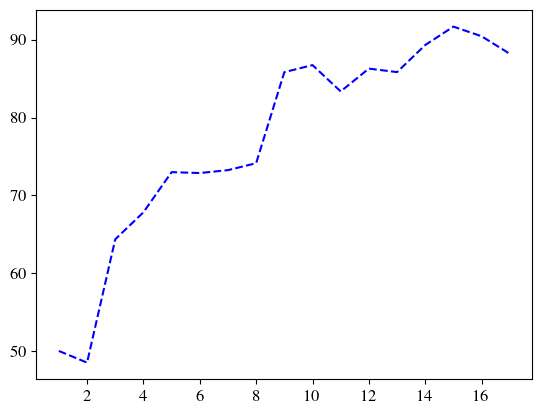

In [209]:
plot_classical_surrogate_acc("logLossBS", max_n_gate=125, max_col_name="train_acc")

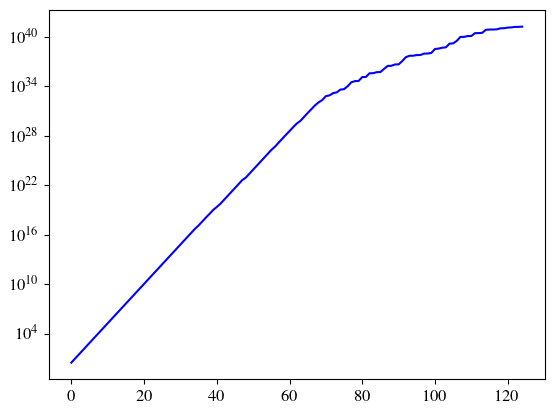

In [210]:
def plot_classical_surrogate_param_counts(bench_folder, max_n_gate, data_set_color='blue', ax=None):
    if ax is None:
        ax = plt.gca()
    model_infos, _ = load(bench_folder, max_n_gate=max_n_gate)
    model_param_counts = [int(info['num_freqs'])*2 + 1 for info in model_infos]
    ax.plot(model_param_counts, label='Number of Parameters', color=data_set_color)
    ax.set_yscale('log')
plot_classical_surrogate_param_counts(bench_folder="logLossBS", max_n_gate=125)

In [211]:
def add_rounded_box(ax, p1, p2, c='gray', alpha=0.3, header=None, footer=None):
    """
    Adds a rounded box with text that automatically shifts horizontally to stay visible
    and includes vertical padding so it doesn't touch the box.
    """
    x0, y0 = p1
    x1, y1 = p2
    width = x1 - x0
    height = y1 - y0

    # 1. Draw the Box
    rgba_face = mpl.colors.to_rgba(c, alpha=alpha)
    rgba_edge = mpl.colors.to_rgba(c, alpha=1.0)

    box = mpl.patches.FancyBboxPatch((x0, y0), width, height,
                                     boxstyle="round,pad=0,rounding_size=2.5",
                                     fc=rgba_face, ec=rgba_edge,
                                     mutation_scale=1, zorder=0)
    ax.add_patch(box)

    # 2. Smart Horizontal Positioning
    xlims = sorted(ax.get_xlim())
    axis_left, axis_right = xlims[0], xlims[1]

    text_x = x0 + width / 2
    align_h = 'center'
    pad_x = (axis_right - axis_left) * 0.02

    if x0 < axis_left and x1 > axis_left:
        text_x = axis_left + pad_x
        align_h = 'left'
    elif x1 > axis_right and x0 < axis_right:
        text_x = axis_right - pad_x
        align_h = 'right'
    elif x0 < axis_left and x1 > axis_right:
        text_x = (axis_left + axis_right) / 2
        align_h = 'center'

    # 3. Add Labels with Vertical Padding using annotate
    # 'offset points' means (0, 5) moves text 5 screen pixels up,
    # regardless of if your axis is 0.001 or 10^40.

    text_kwargs = dict(ha=align_h, color=rgba_edge, zorder=1, textcoords='offset points')

    if header is not None:
        ax.annotate(header, xy=(text_x, y1), xytext=(0, 2.5), va='bottom', **text_kwargs)

    if footer is not None:
        ax.annotate(footer, xy=(text_x, y0), xytext=(0, -2.5), va='top', **text_kwargs)

In [212]:
def plot_fading_line(ax, y, start_idx, end_idx, color, fade_color='gray', x=None, label=None):
    """
    Plots a line that transitions from 'color' to 'fade_color' between start_idx and end_idx.
    """
    y = np.array(y)
    if x is None:
        x = np.arange(len(y))
    else:
        x = np.array(x)

    # 1. Create segments (N points -> N-1 segments)
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # 2. Create Color Array
    n_segments = len(segments)

    # Convert colors to RGB arrays
    c_start = np.array(mpl.colors.to_rgb(color))
    c_end = np.array(mpl.colors.to_rgb(fade_color))

    # Initialize all segments with the final fade color (optimization)
    colors = np.tile(c_end, (n_segments, 1))

    # A. Solid Color Section (Before Fade)
    if start_idx > 0:
        colors[:start_idx] = c_start

    # B. Gradient Section (During Fade)
    # Clamp indices to ensure we don't crash if indices are out of bounds
    safe_start = max(0, start_idx)
    safe_end = min(n_segments, end_idx)
    fade_len = safe_end - safe_start

    if fade_len > 0:
        # Generate interpolation weights (0.0 to 1.0)
        t = np.linspace(0, 1, fade_len)[:, np.newaxis]
        # Interpolate: (1-t)*Start + t*End
        colors[safe_start:safe_end] = c_start * (1 - t) + c_end * t

    # 3. Add to Plot
    lc = mpl.collections.LineCollection(segments, colors=colors, label=label)
    ax.add_collection(lc)

    return lc

In [213]:
def add_benchmark_line(ax, y_value, label, color='black', linestyle='-', linewidth=0.8, text_offset=0):
    """
    Adds a horizontal benchmark line with a label sitting on top of it at the right axis edge.

    Parameters:
    ax : matplotlib axis
    y_value : float (data coordinate)
    label : str (text to display)
    text_offset : float (points), optional vertical shift for text
    """
    # 1. The Line
    ax.axhline(y_value, color=color, linewidth=linewidth, linestyle=linestyle, zorder=1)

    # 2. The Label
    # We use a transform that blends Axes coords (X) and Data coords (Y)
    trans = ax.get_yaxis_transform()

    # Add text
    txt = ax.text(1.0, y_value, label,
                  color=color, fontsize='small',
                  ha='right',    # Align right edge of text to x=1.0
                  va='bottom',   # Sit on top of the line
                  transform=trans)

    # Optional: Nudge text if needed (using offset_copy to move in 'points')
    if text_offset != 0:
        from matplotlib.transforms import offset_copy
        # Shift 'text_offset' points vertically
        txt.set_transform(offset_copy(trans, fig=ax.figure, y=text_offset, units='points'))

# Integrate in original plotting code

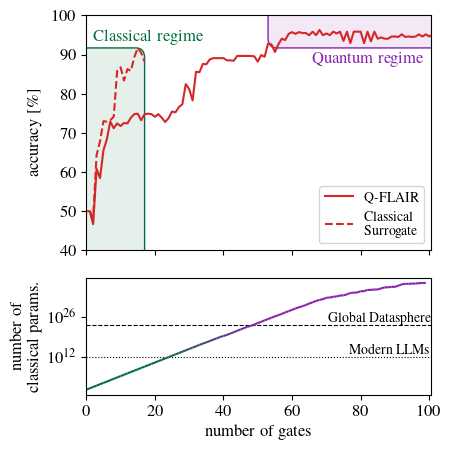

In [258]:
mpl.rcParams.update({'text.usetex':True,'font.size': 12, 'font.family': 'serif', 'font.serif': ['Times', 'Computer Modern']})

color = ['tab:red','orange','tab:purple','green']
color_classical_regime = tuple(np.array([0, 110, 61])/255)
color_quantum_regime = tuple(np.array([136, 33, 176])/255)


fig, (ax1, ax2) = plt.subplots(2, 1,
                               figsize=(11.69*0.4, (4+8.27)*0.38),
                               sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})

# ONLY SINGLE DATASET PLOT FOR NOW (USE SECOND PLOT FOR CLASSICAL PARAMETER CURVE)
# ==========================================
# RIGHT PLOT (ax2): logLossMN
# ==========================================
#
# # 1. Q-FLAIR
# name = 'logLossMN'
# path_file_mn = os.path.join(Q_FLAIR_RESULTS_DIR, name, 'ACC_test.txt')
# ACC0 = np.genfromtxt(path_file_mn, usecols=0, skip_header=1)
# ACC1 = np.genfromtxt(path_file_mn, usecols=1, skip_header=1)
# ACC0 = np.array([0.5, *ACC0])
# ACC1 = np.array([0.5, *ACC1])
# ACCaverOpt_mn = (ACC0 + ACC1) * 0.5
# gatesOpt_mn = np.linspace(0, len(ACCaverOpt_mn)-1, len(ACCaverOpt_mn))
#
# # Plot Q-FLAIR
# curve1, = ax2.plot(gatesOpt_mn, ACCaverOpt_mn*100, '-', color=color[2], label='Q-FLAIR', fillstyle='none')
# # 2. Classical Surrogate Benchmark (New)
# # Using max_n_gate=56 based on your original ax2.set_xlim(0, 56+0.5)
# plot_classical_surrogate_acc(
#     name,
#     max_n_gate=125,
#     max_col_name="train_acc",
#     ax=ax2,
#     data_set_color=color[2],
# )

# ==========================================
# LEFT PLOT (ax1): logLossBS
# ==========================================

# 1. Q-FLAIR (Optimized gate)
name = 'logLossBS'
path_file_bs = os.path.join(Q_FLAIR_RESULTS_DIR, name, 'ACC_test.txt')
ACC0 = np.genfromtxt(path_file_bs, usecols=0, skip_header=1)
ACC1 = np.genfromtxt(path_file_bs, usecols=1, skip_header=1)
ACC0 = np.array([0.5, *ACC0])
ACC1 = np.array([0.5, *ACC1])
ACCaverOpt_bs = (ACC0 + ACC1) * 0.5
gatesOpt_bs = np.linspace(0, len(ACCaverOpt_bs)-1, len(ACCaverOpt_bs))

max_n_gates = 100
ax1.set_xlim(0, max_n_gates + 0.5)

# Plot Q-FLAIR
curve2, = ax1.plot(gatesOpt_bs, ACCaverOpt_bs*100, '-', color=color[0], label='Q-FLAIR', fillstyle='none')

# 2. Classical Surrogate Benchmark (New)
# Using max_n_gate=95 based on your original ax1.set_xlim(0, 95+0.5)
model_infos, comb_df = plot_classical_surrogate_acc(
    name,
    max_n_gate=max_n_gates,
    max_col_name="train_acc",
    ax=ax1,
    data_set_color=color[0]
)

# Add regime boxes:
classical_accs = comb_df['val_acc'].to_numpy() * 100
quantum_accs = np.asarray(ACCaverOpt_bs) * 100
n_gates = comb_df['n_gate'].to_numpy()
max_n_gates_classical_regime = n_gates.max()
max_classical_acc = classical_accs.max()
add_rounded_box(ax1, (-10, -10), (max_n_gates_classical_regime, max_classical_acc), c=color_classical_regime, alpha=0.1, header="Classical regime")
n_gates = np.arange(len(quantum_accs))
n_gates_quantum_regime = n_gates[quantum_accs > max_classical_acc]

if len(n_gates_quantum_regime) > 0:
    min_n_gates_quantum_regime = n_gates_quantum_regime.min()
    add_rounded_box(ax1, (min_n_gates_quantum_regime, max_classical_acc), (max_n_gates+3, 110), c=color_quantum_regime, alpha=0.1, footer="Quantum regime")
    #connect boxes with a vertical line
    #n_steps = 100
    #plot_fading_line(ax1, [max_classical_acc]*n_steps, start_idx=0, end_idx=n_steps - 1, color=color_classical_regime, fade_color=color_quantum_regime)
else:
    min_n_gates_quantum_regime = n_gates.max() + 1



# Plot classical parameter counts via plot_fading_line:
model_param_counts = np.array([int(info['num_freqs'])*2 + 1 for info in model_infos])
plot_fading_line(
    ax2,
    model_param_counts,
    start_idx=max_n_gates_classical_regime,
    end_idx=min_n_gates_quantum_regime,
    color=color_classical_regime,
    fade_color=color_quantum_regime,
)
# add horizontal lines for comparison:
# LLM 10^12 (trillion) parameters
# 1. LLM Benchmark (~1 Trillion)
llm_count = 1e12
add_benchmark_line(ax2, llm_count, r'Modern LLMs', linestyle=':')

# 2. Global Datasphere (~175 Zettabytes approx 10^23 bytes -> ~10^23 params)
# You can easily add more now:
global_data_count = 1.75e23
add_benchmark_line(ax2, global_data_count, r'Global Datasphere', linestyle='--')

custom_param_ticks = np.array([llm_count, global_data_count, max(model_param_counts)], dtype=float)

# ==========================================
# FORMATTING
# ==========================================

# Left Plot Limits (BS)
ax1.set_ylim(0.4 * 100, 1 * 100)
ax1.set_ylabel(r'accuracy [\%]', fontsize='medium')
ax1.legend(fontsize='small')


ax2.set_yscale('log')
ax2.set_xlabel('number of gates', fontsize='medium')
ax2.set_ylabel('number of\nclassical params.', fontsize='medium')
fig.align_ylabels([ax1, ax2])

# Global Labels
#fig.supxlabel('number of gates', y=0.1, x=0.55, fontsize='medium')

# in case parameter scaling plot should be hidden:
#ax2.set_visible(False)


plt.tight_layout()
save_path = f'plots/Acc_classical_surrogate_paper_{name}.pdf'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path)
plt.show()